# Metient-calibrate

##### This tutorial is intended for those who want to run Metient in calibrate mode, where they already have the observed clone percentages and wish to label the clone tree. 

##### To run this notebook, you'll need metient installed (follow installation instructions on the github README)

### Import libraries and setup paths

In [1]:
import os
import metient as met
import warnings
warnings.filterwarnings('ignore')

### Setup paths
# Path to where our input clone trees and tsvs are located
notebook_dir = '/data1/morrisq/divyak/projects/metient/tutorial'
input_dir = os.path.join(notebook_dir, "inputs")
# Path to save outputs
output_dir = os.path.join(notebook_dir, "2_outputs")

### An example of the expected tsv file format for NSCLC patient CRUK0010
**The required columns are:**
`anatomical_site_index, anatomical_site_label, cluster_index, cluster_label, present, site_category, num_mutations` (see `../README.md` for description of each column)

In [2]:
import pandas as pd
df = pd.read_csv(os.path.join(input_dir, "CRUK0010_SNVs.tsv"), sep="\t")
df

,anatomical_site_index,anatomical_site_label,cluster_index,cluster_label,present,site_category,num_mutations
0,0,primary_SU_T1,0,SPTAN1;SETD2,0,primary,58
1,1,LN_SU_FLN1,0,SPTAN1;SETD2,0,metastasis,58
2,2,metachronousMet_BR_LN1,0,SPTAN1;SETD2,0,metastasis,58
3,3,metachronousMet_BR_LN2,0,SPTAN1;SETD2,0,metastasis,58
4,4,metachronousMet_BR_LN3,0,SPTAN1;SETD2,0,metastasis,58
...,...,...,...,...,...,...,...
70,0,primary_SU_T1,14,OTUD7B;BVES-AS1,0,primary,5
71,1,LN_SU_FLN1,14,OTUD7B;BVES-AS1,0,metastasis,5
72,2,metachronousMet_BR_LN1,14,OTUD7B;BVES-AS1,0,metastasis,5
73,3,metachronousMet_BR_LN2,14,OTUD7B;BVES-AS1,0,metastasis,5


## Step 1: Load filepaths to clone trees and tsv files for each patient

In [3]:
# Configure inputs
patients = ["CRUK0003", "CRUK0010", "CRUK0013", "CRUK0029", "CRUK0590"]
clone_tree_fns = [os.path.join(input_dir, f"{patient}_tree.txt") for patient in patients]
ref_var_fns = [os.path.join(input_dir, f"{patient}_SNVs.tsv") for patient in patients]
calibration_type = "genetic"

## Step 2: Run Metient-calibrate

Saving results to /data1/morrisq/divyak/projects/metient/tutorial/2_outputs/calibrate
Overwriting existing directory at /data1/morrisq/divyak/projects/metient/tutorial/2_outputs/calibrate

*** Calibrating for patient: CRUK0003 ***
O: None
Tumor samples: ['primary_SU_T1', 'LN_SU_FLN1']
Input tree has 16 nodes, calculated sample size: 2304


100%|██████████| 2800/2800 [01:16<00:00, 30.52it/s]

Number of final solutions: 1

*** Calibrating for patient: CRUK0010 ***
O: None
Tumor samples: ['primary_SU_T1', 'LN_SU_FLN1', 'metachronousMet_BR_LN1', 'metachronousMet_BR_LN2', 'metachronousMet_BR_LN3']
Input tree has 15 nodes, calculated sample size: 2648


100%|█████████▉| 2796/2800 [01:01<00:00, 53.34it/s]

Number of final solutions: 1

*** Calibrating for patient: CRUK0013 ***
O: None
Tumor samples: ['LN_SU_LN1', 'LN_SU_LN2', 'primary_SU_T1', 'LN_SU_FLN1', 'LN_SU_FLN2']
Input tree has 7 nodes, calculated sample size: 2328


...

100%|██████████| 2800/2800 [01:35<00:00, 22.69it/s]

Number of final solutions: 2

*** Calibrating for patient: CRUK0590 ***
O: None
Tumor samples: ['primary_SU_T1', 'metachronousMet_BR_T1.FR2', 'metachronousMet_BR_T1.FR1', 'metachronousMet_BR_T3.FR1', 'LN_SU_FLN1']
Input tree has 19 nodes, calculated sample size: 2808


100%|█████████▉| 2798/2800 [01:45<00:00, 33.30it/s]

Number of final solutions: 2
Calibrating parsimony weights to match genetic distance distribution
Calibrating to 3 patients
Optimized thetas: tensor([0.75, 0.16, 0.09], grad_fn=<DivBackward0>)
CRUK0003_primary_SU_T1


<Figure size 640x480 with 0 Axes>

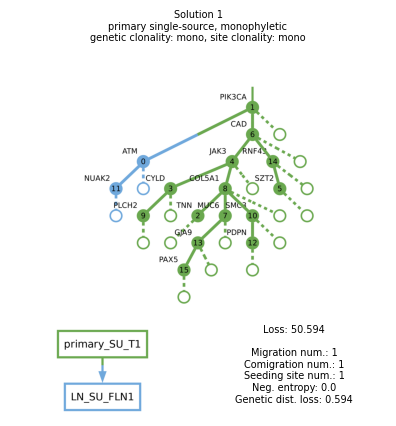

CRUK0010_primary_SU_T1


<Figure size 640x480 with 0 Axes>

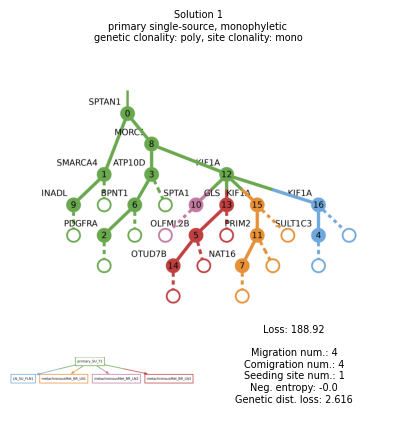

CRUK0013_primary_SU_T1


<Figure size 640x480 with 0 Axes>

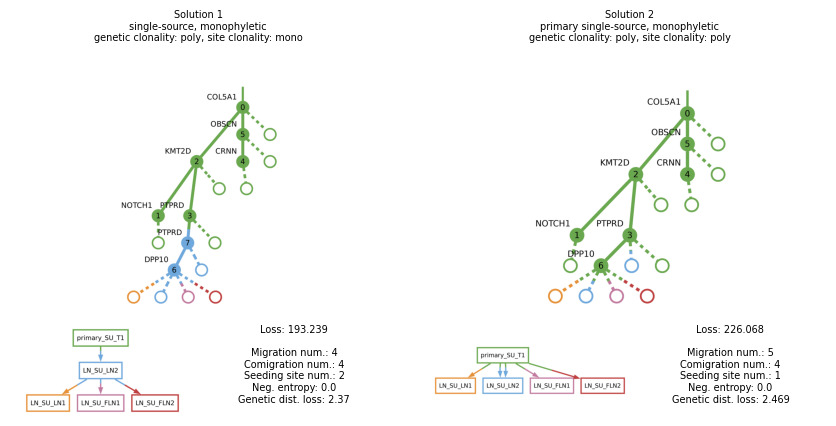

CRUK0029_primary_SU_T1


<Figure size 640x480 with 0 Axes>

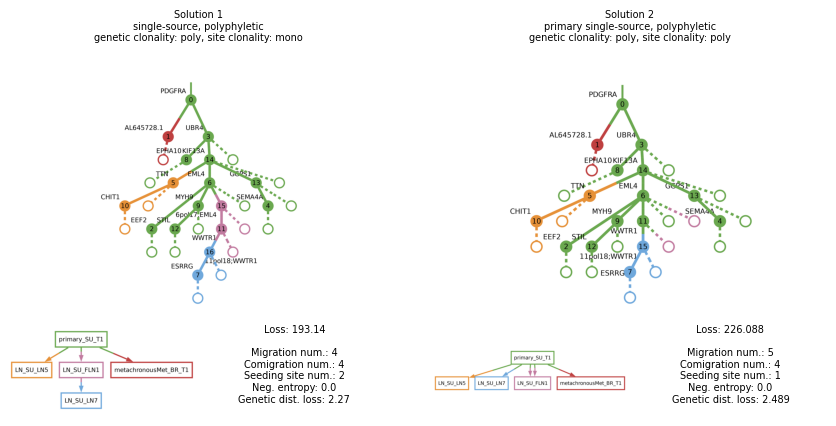

CRUK0590_primary_SU_T1


<Figure size 640x480 with 0 Axes>

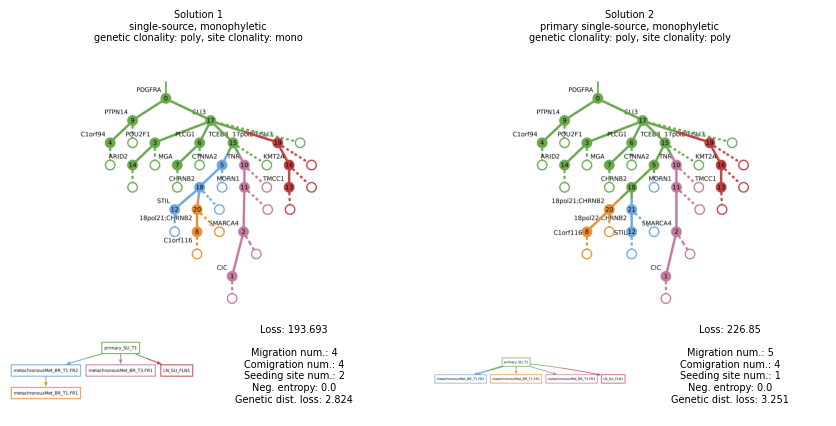

[0.7458996772766113, 0.1627916842699051, 0.09130862355232239]

In [4]:
print_config = met.PrintConfig(visualize=True, verbose=False, k_best_trees=10)
met.calibrate_label_clone_tree(clone_tree_fns, ref_var_fns, print_config, output_dir, patients, calibration_type, solve_polytomies=True)

## Step 3: Use the pickle file outputs for downstream analysis

### In addition to the visualizations that Metient provides, we also save pkl.gz files for each Metient run that contain all the results of the run.

In [ ]:
import gzip
import pickle

with gzip.open(os.path.join(output_dir,"calibrate", "CRUK0590_primary_SU_T1.pkl.gz") ,"rb") as f:
    pckl = pickle.load(f)
print(pckl.keys())

# Get classifications for clonality and phyleticity, weighted by probability of each solution
print("Overall genetic clonality:", met.weighted_genetic_clonality(pckl))
print("Overall site clonality:", met.weighted_site_clonality(pckl))
print("Overall phyleticity:", met.weighted_phyleticity(pckl))

print("\nSolution probabilities:", pckl['probabilities'])

# Look at individual solutions:
for idx in range(len(pckl['node_labels'])):
    print("\n===============================")
    print("Solution {idx} probability: {prob:.4f}".format(idx=idx, prob=pckl['probabilities'][idx]))
    # V is the best node labeling
    V = pckl['node_labels'][idx]
    # A is the adjacency matrix that is the input clone tree + inferred witness nodes + polytomy resolved nodes
    parents = pckl['parents'][idx]
    A = met.adjacency_matrix_from_parents(parents)
    # G represents the migration graph
    G = met.migration_graph(V, A)
    print("\nMigration graph:\n", G)

    node_info = pckl['node_info'][idx]

    # Show other information about this inferred migration history
    print("\nSeeding pattern:", met.seeding_pattern(V, A))
    print("Seeding clusters:", met.seeding_clusters(V, A,node_info))
    print("Phyleticity:", met.phyleticity(V, A, node_info))
    print("Site clonality:", met.site_clonality(V, A))
    print("Genetic clonality:", met.genetic_clonality(V, A,node_info))

dict_keys(['node_labels', 'losses', 'node_info', 'parents', 'anatomical_sites', 'loss_info', 'primary_site', 'probabilities', 'soft_labeling', 'genetic_distances', 'observed_proportions'])
Overall genetic clonality: polyclonal
Overall site clonality: monoclonal
Overall phyleticity: monophyletic

Solution probabilities: [0.88079708 0.11920292]

Solution 0 probability: 0.8808

Migration graph:
 tensor([[0., 1., 0., 1., 1.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

Seeding pattern: single-source
Seeding clusters: [17, 10, 18, 5]
Phyleticity: monophyletic
Site clonality: monoclonal
Genetic clonality: polyclonal

Solution 1 probability: 0.1192

Migration graph:
 tensor([[0., 2., 1., 1., 1.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

Seeding pattern: primary single-source
Seeding clusters: [17, 10, 18, 5]
Phyleticity: monophyletic
Si

100%|██████████| 2800/2800 [02:03<00:00, 33.30it/s]